In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv("bearingdata.csv")
df

##



,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1
...,...,...,...,...,...,...,...,...,...,...
2295,0.21425,-0.19839,0.010769,0.064100,0.064983,-0.212497,-0.119312,3.297037,6.034174,Normal_1
2296,0.21967,-0.20882,0.013136,0.068654,0.069883,-0.061308,-0.295122,3.143410,5.319958,Normal_1
2297,0.20799,-0.21613,0.012571,0.067128,0.068279,-0.154754,-0.071405,3.046161,5.431299,Normal_1
2298,0.21425,-0.22405,0.012608,0.066813,0.067977,-0.326966,0.023662,3.151821,5.391672,Normal_1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   max       2300 non-null   float64
 1   min       2300 non-null   float64
 2   mean      2300 non-null   float64
 3   sd        2300 non-null   float64
 4   rms       2300 non-null   float64
 5   skewness  2300 non-null   float64
 6   kurtosis  2300 non-null   float64
 7   crest     2300 non-null   float64
 8   form      2300 non-null   float64
 9   fault     2300 non-null   object 
dtypes: float64(9), object(1)
memory usage: 179.8+ KB


In [5]:
df.describe()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
mean,1.575079,-1.550994,0.015711,0.341601,0.342289,-0.042251,2.664444,4.173130,26.544769
std,1.578422,1.602706,0.006469,0.305279,0.304813,0.180774,4.411096,1.148349,29.209702
min,0.157300,-6.292600,0.003246,0.059140,0.061067,-1.089928,-0.803795,2.428511,3.484429
25%,0.456398,-2.174975,0.011236,0.135506,0.136374,-0.103426,-0.015164,3.260382,7.413359
50%,0.794510,-0.733700,0.013730,0.188551,0.190662,-0.002466,0.816970,3.921650,13.122811
75%,2.278425,-0.426987,0.018638,0.555589,0.555671,0.061093,3.902286,4.815876,39.911894
max,6.825900,-0.160220,0.038386,1.256577,1.256311,1.059512,30.385326,8.821577,313.742612


In [ ]:
# 결함 유형 분포 확인
df['fault'].value_counts()


fault
Ball_007_1    230
Ball_014_1    230
Ball_021_1    230
IR_007_1      230
IR_014_1      230
IR_021_1      230
OR_007_6_1    230
OR_014_6_1    230
OR_021_6_1    230
Normal_1      230
Name: count, dtype: int64

In [9]:
# 결함 그룹 단순화(4종 분류)-->볼, 내부, 외부
def simplify_fault(label):
    if 'Ball' in label:
        return 'Ball'
    elif 'IR' in label:
        return 'IR'
    elif 'OR' in label:
        return 'OR'
    else:
        return 'Normal'

df['fault_simple'] = df['fault'].apply(simplify_fault)


In [ ]:
# 결함 그룹별 통계 피쳐 평균 비교
df.groupby('fault_simple').mean(numeric_only=True)


,max,min,mean,sd,rms,skewness,kurtosis,crest,form
fault_simple,,,,,,,,,
Ball,0.595322,-0.556972,0.014115,0.159051,0.159758,0.016483,0.949462,3.700875,12.488163
IR,1.515122,-1.441332,0.021118,0.359442,0.360491,-0.020293,2.086873,4.374890,25.454475
Normal,0.205093,-0.206493,0.012488,0.065046,0.066265,-0.173084,-0.095627,3.093996,5.529295
OR,3.071454,-3.102847,0.012973,0.598497,0.598627,-0.079332,5.877020,4.803336,48.696827


<Axes: xlabel='fault_simple', ylabel='kurtosis'>

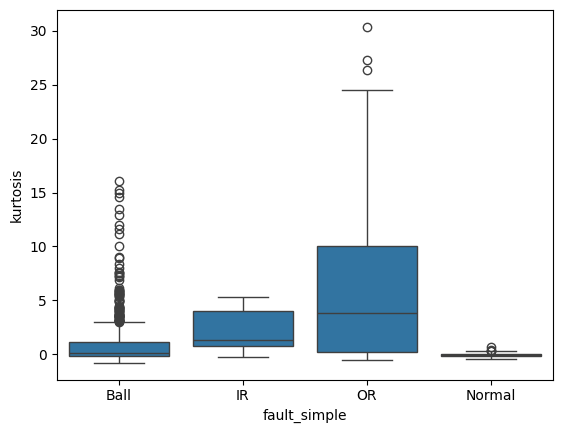

In [11]:
# 결함 그룹별 분포 시각화
import seaborn as sns
sns.boxplot(data=df, x='fault_simple', y='kurtosis')
